In [10]:
from langgraph.graph import START, END, StateGraph

from typing import TypedDict

In [ ]:
from dotenv import load_dotenv
import os
load_dotenv()

In [4]:
class ResumeState(TypedDict):
    resume: str
    skills_feedback: str
    exp_feedback: str
    tone_feedback: str
    final_report: str

In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(model='llama-3.3-70b-versatile',
               api_key=os.getenv('GROQ_API_KEY')) #type: ignore

In [7]:
async def check_skills(state: ResumeState):
    response = await llm.ainvoke(f'Evaluate skills in this resume (only output feedback): {state['resume']}')
    return {'skills_feedback': response.content}

In [8]:
async def check_experience(state: ResumeState):
    response = await llm.ainvoke(f'Evaluate experience in this resume: {state['resume']}')
    return {'exp_feedback': response.content}

In [9]:
async def check_tone(state: ResumeState):
    response = await llm.ainvoke(f'Evaluate the tone in this resume: {state['resume']}')
    return {'tone_feedback': response.content}

In [11]:
def compile_report(state: ResumeState):
    response = llm.invoke(f'''Combine following feedback into one final resume report: 
                          SKILL: {state['skills_feedback']}
                          EXPERIENCE: {state['exp_feedback']}
                          TONE: {state['tone_feedback']}
                          
                          Give an overall score out of 10 and key recommendations.''')
    return {'final_report': response.content}

In [12]:
graph = StateGraph(ResumeState)

#add nodes
graph.add_node('check_skills', check_skills)
graph.add_node('check_experience', check_experience)
graph.add_node('check_tone', check_tone)
graph.add_node('compile_report', compile_report)

#add edges
graph.add_edge(START, 'check_skills')
graph.add_edge(START, 'check_experience')
graph.add_edge(START, 'check_tone')

graph.add_edge('check_skills', 'compile_report')
graph.add_edge('check_experience', 'compile_report')
graph.add_edge('check_tone', 'compile_report')

graph.add_edge('compile_report', END)

app = graph.compile()


In [13]:
from IPython.display import display, Image
def draw_graph(app):
    display(Image(app.get_graph().draw_mermaid_png()))
    

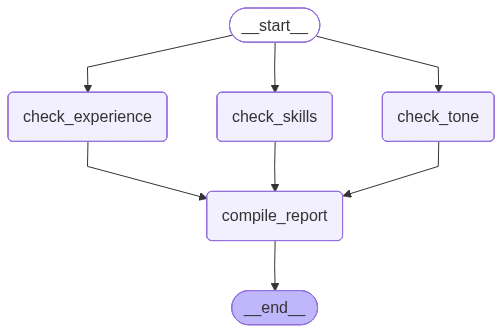

In [14]:
draw_graph(app)

In [21]:
result = await app.ainvoke({
    "resume": """
        Alex Morgan | Full Stack Developer
        Email: alex.morgan@email.com | GitHub: github.com/alexmorgan

        SKILLS:
        - Languages: JavaScript, TypeScript, Python
        - Frontend: React, Next.js, Tailwind CSS
        - Backend: Node.js, Express, FastAPI
        - Database: PostgreSQL, MongoDB
        - Tools: Docker, Git, AWS (EC2, S3)

        EXPERIENCE:
        Software Engineer — TechNova Inc. (2021 – Present)
        - Built and maintained 3 customer-facing React apps serving 50k users
        - Designed REST APIs using FastAPI, reducing response time by 40%
        - Collaborated with a team of 6 engineers in an agile environment

        Junior Developer — ByteWorks Studio (2019 – 2021)
        - Developed internal dashboards using Vue.js and Node.js
        - Wrote unit tests with Jest, increasing code coverage from 42% to 78%
        - Assisted in migrating legacy PHP codebase to Node.js microservices

        EDUCATION:
        B.Sc Computer Science — State University (2015 – 2019)
        GPA: 3.6 / 4.0

        PROJECTS:
        - TaskFlow: A Kanban board app built with Next.js + PostgreSQL (500+ GitHub stars)
        - OpenWeatherBot: Telegram bot using Python + OpenWeatherMap API
    """,
    "skills_feedback": "",
    "exp_feedback": "",
    "tone_feedback": "",
    "final_report": ""
})

In [22]:
print(result["final_report"])

**Final Resume Report:**

The candidate, Alex Morgan, demonstrates a strong foundation in full-stack development, with a good balance of frontend, backend, database, and tooling skills. With 4 years of professional experience, Alex has worked on various projects, including large-scale React applications, REST APIs, and legacy code migration. The candidate's technical skills, experience, and achievements are well-documented, showcasing their versatility and ability to adapt to different project requirements.

**Overall Assessment:**
Alex Morgan has a strong foundation in full-stack development, with experience working on both frontend and backend technologies. They have demonstrated ability to collaborate with teams, solve problems, and optimize code. With some additional experience in cloud platforms, DevOps tools, and machine learning/AI, Alex could become a well-rounded and versatile software engineer.

**Key Strengths:**

1. Full-stack development experience
2. Team collaboration
3.

**Final Resume Report:**

The candidate, Alex Morgan, demonstrates a strong foundation in full-stack development, with a good balance of frontend, backend, database, and tooling skills. With 4 years of professional experience, Alex has worked on various projects, including large-scale React applications, REST APIs, and legacy code migration. The candidate's technical skills, experience, and achievements are well-documented, showcasing their versatility and ability to adapt to different project requirements.

**Overall Assessment:**
Alex Morgan has a strong foundation in full-stack development, with experience working on both frontend and backend technologies. They have demonstrated ability to collaborate with teams, solve problems, and optimize code. With some additional experience in cloud platforms, DevOps tools, and machine learning/AI, Alex could become a well-rounded and versatile software engineer.

**Key Strengths:**

1. Full-stack development experience
2. Team collaboration
3. Problem-solving and optimization
4. Testing and quality assurance

**Notable Achievements:**

1. Building and maintaining customer-facing apps
2. Legacy code migration
3. Open-source projects

**Gaps and Areas for Improvement:**

1. Limited experience with cloud platforms
2. No experience with DevOps tools
3. No experience with machine learning or artificial intelligence

**Tone:**
The tone of this resume is professional, confident, fact-based, concise, and technical, making it well-suited for a technical audience.

**Overall Score: 8.5/10**

**Key Recommendations:**

1. **Gain experience with cloud platforms**: Consider working with Google Cloud, Microsoft Azure, or other cloud platforms to broaden your skillset.
2. **Explore DevOps tools**: Familiarize yourself with tools like Kubernetes, Jenkins, or CircleCI to enhance your DevOps skills.
3. **Develop machine learning or AI experience**: Take online courses or work on projects that incorporate machine learning or AI to expand your skillset.
4. **Add a brief summary or introduction**: Consider adding a brief summary or introduction to your resume to highlight your unique strengths and career goals, and add a touch of personality to your resume.
5. **Pursue relevant certifications or courses**: Consider obtaining relevant certifications or taking recent courses to demonstrate your commitment to ongoing learning and professional development.

By addressing these areas for improvement and continuing to develop your skills and experience, you can become a highly competitive candidate in the job market.